Saving all outputs to: E:\MCT Paper_Updated\01_Data_Sanity
1320 rpm | BF | files = 112
1320 rpm | GF | files = 111
1320 rpm | N | files = 116
1320 rpm | TF | files = 112
1440 rpm | BF | files = 112
1440 rpm | GF | files = 110
1440 rpm | N | files = 112
1440 rpm | TF | files = 112

Loaded summary
Source 1320 samples: 451
Target 1440 samples: 446
Counts per class source: {'BF': 112, 'GF': 111, 'N': 116, 'TF': 112}
Counts per class target: {'BF': 112, 'GF': 110, 'N': 112, 'TF': 112}

Target split
Target train (unlabeled) samples: 356
Target test  (labeled) samples  : 90
Counts per class target train: {'GF': 88, 'N': 89, 'BF': 90, 'TF': 89}
Counts per class target test : {'GF': 22, 'N': 23, 'TF': 23, 'BF': 22}

Dataset summary dict (paste in paper if needed):
{'Source_1320': {'n_samples': 451, 'channels': 2, 'len_min': 25600, 'len_max': 25600, 'len_mean': 25600.0, 'fs_min': 25600.0, 'fs_max': 25600.0, 'fs_unique_count': 1}, 'TargetTrain_Unl_1440': {'n_samples': 356, 'channels': 2, 'len_min

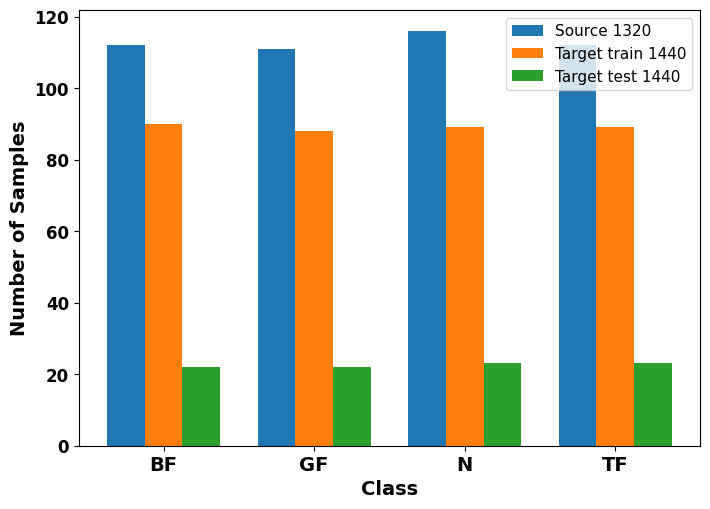

Saved: E:\MCT Paper_Updated\01_Data_Sanity\figs\Fig1_ClassDistribution_2000dpi.png


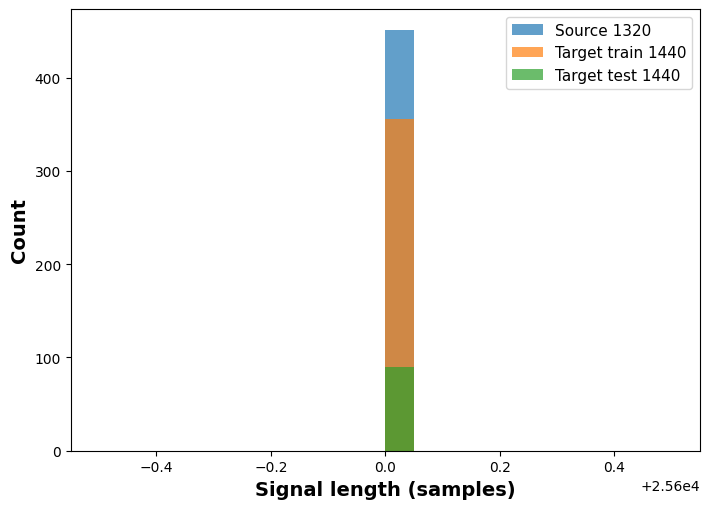

Saved: E:\MCT Paper_Updated\01_Data_Sanity\figs\Fig2_SignalLengthDistribution_2000dpi.png

STEP 1 complete.
Now paste the printed dataset summary here, and confirm the figures exist in:
E:\MCT Paper_Updated\01_Data_Sanity\figs


In [1]:
# =========================================================
# STEP 1 (Fresh Pipeline): Load data + Target split + Paper-ready sanity outputs
# Novel model track: Physics Trust Learning DA (next steps)
# Saves results to: E:\MCT Paper_Updated\01_Data_Sanity\
# =========================================================

import os, glob, json
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

np.random.seed(42)

# -----------------------------
# Main paper directory
# -----------------------------
MAIN_DIR = r"E:\MCT Paper_Updated"
OUT_DIR  = os.path.join(MAIN_DIR, "01_Data_Sanity")
FIG_DIR  = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

print("Saving all outputs to:", OUT_DIR)

# -----------------------------
# Dataset paths (edit only if needed)
# -----------------------------
base1320 = r"E:\New Paper Work 2\Vibration_1320"
base1440 = r"E:\New Paper Work 2\Vibration_1440"

# Classes and folder maps
class_names = ["BF", "GF", "N", "TF"]
class_to_id = {"BF":0, "GF":1, "N":2, "TF":3}

folders1320 = {"BF":"Vib_BF1320_1","GF":"Vib_GF1320_1","N":"Vib_N1320_1","TF":"Vib_TF1320_1"}
folders1440 = {"BF":"Vib_BF1440_1","GF":"Vib_GF1440_1","N":"Vib_N1440_1","TF":"Vib_TF1440_1"}

# -----------------------------
# Loader
# -----------------------------
def load_domain(base_path, folder_map, rpm_value):
    X, Y, D, FS, paths = [], [], [], [], []

    for cls in class_names:
        folder = os.path.join(base_path, folder_map[cls])
        files = sorted(glob.glob(os.path.join(folder, "*.mat")))
        print(f"{rpm_value} rpm | {cls} | files = {len(files)}")

        for fp in files:
            mat = sio.loadmat(fp)

            if ("signals" not in mat) or ("fs" not in mat):
                raise KeyError(f"Missing 'signals' or 'fs' in file: {fp}")

            sig = np.array(mat["signals"], dtype=np.float32)
            fs_val = float(np.squeeze(mat["fs"]))

            if sig.ndim != 2:
                raise ValueError(f"'signals' must be 2D. Got shape={sig.shape} in {fp}")
            if sig.shape[0] != 2:
                raise ValueError(f"Expected 2-channel signals. Got shape={sig.shape} in {fp}")

            X.append(sig)
            Y.append(cls)
            D.append(int(rpm_value))
            FS.append(fs_val)
            paths.append(fp)

    return X, Y, D, FS, paths

# -----------------------------
# Load source and target
# -----------------------------
Xs, Ys, Ds, FSs, Ps = load_domain(base1320, folders1320, 1320)
Xt, Yt, Dt, FSt, Pt = load_domain(base1440, folders1440, 1440)

print("\nLoaded summary")
print("Source 1320 samples:", len(Xs))
print("Target 1440 samples:", len(Xt))

src_counts = Counter(Ys)
tgt_counts = Counter(Yt)
print("Counts per class source:", dict(src_counts))
print("Counts per class target:", dict(tgt_counts))

# -----------------------------
# Split target: 80% unlabeled train, 20% labeled test
# -----------------------------
y_target_ids = np.array([class_to_id[y] for y in Yt], dtype=np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train_t, idx_test_t = next(sss.split(np.zeros(len(y_target_ids)), y_target_ids))

Xt_train = [Xt[i] for i in idx_train_t]
Yt_train = [Yt[i] for i in idx_train_t]
FSt_train = [FSt[i] for i in idx_train_t]

Xt_test = [Xt[i] for i in idx_test_t]
Yt_test = [Yt[i] for i in idx_test_t]
FSt_test = [FSt[i] for i in idx_test_t]

print("\nTarget split")
print("Target train (unlabeled) samples:", len(Xt_train))
print("Target test  (labeled) samples  :", len(Xt_test))

tu_counts = Counter(Yt_train)
tt_counts = Counter(Yt_test)
print("Counts per class target train:", dict(tu_counts))
print("Counts per class target test :", dict(tt_counts))

# -----------------------------
# Sanity checks
# -----------------------------
def sig_lengths(X_list):
    return [int(x.shape[-1]) for x in X_list]

src_L = sig_lengths(Xs)
tu_L  = sig_lengths(Xt_train)
tt_L  = sig_lengths(Xt_test)

src_fs = np.array(FSs, dtype=np.float64)
tu_fs  = np.array(FSt_train, dtype=np.float64)
tt_fs  = np.array(FSt_test, dtype=np.float64)

summary = {
    "Source_1320": {
        "n_samples": len(Xs),
        "channels": int(Xs[0].shape[0]),
        "len_min": int(np.min(src_L)),
        "len_max": int(np.max(src_L)),
        "len_mean": float(np.mean(src_L)),
        "fs_min": float(np.min(src_fs)),
        "fs_max": float(np.max(src_fs)),
        "fs_unique_count": int(len(np.unique(np.round(src_fs, 6))))
    },
    "TargetTrain_Unl_1440": {
        "n_samples": len(Xt_train),
        "channels": int(Xt_train[0].shape[0]),
        "len_min": int(np.min(tu_L)),
        "len_max": int(np.max(tu_L)),
        "len_mean": float(np.mean(tu_L)),
        "fs_min": float(np.min(tu_fs)),
        "fs_max": float(np.max(tu_fs)),
        "fs_unique_count": int(len(np.unique(np.round(tu_fs, 6))))
    },
    "TargetTest_1440": {
        "n_samples": len(Xt_test),
        "channels": int(Xt_test[0].shape[0]),
        "len_min": int(np.min(tt_L)),
        "len_max": int(np.max(tt_L)),
        "len_mean": float(np.mean(tt_L)),
        "fs_min": float(np.min(tt_fs)),
        "fs_max": float(np.max(tt_fs)),
        "fs_unique_count": int(len(np.unique(np.round(tt_fs, 6))))
    }
}

print("\nDataset summary dict (paste in paper if needed):")
print(summary)

# -----------------------------
# Save summary TXT and JSON
# -----------------------------
txt_path  = os.path.join(OUT_DIR, "dataset_summary.txt")
json_path = os.path.join(OUT_DIR, "dataset_summary.json")

with open(txt_path, "w", encoding="utf-8") as f:
    f.write("Dataset Sanity Report\n")
    f.write("=====================\n\n")
    for k in summary:
        f.write(f"{k}\n")
        for kk, vv in summary[k].items():
            f.write(f"  {kk}: {vv}\n")
        f.write("\n")
    f.write("Class counts\n")
    f.write("-----------\n")
    f.write(f"Source_1320: {dict(src_counts)}\n")
    f.write(f"TargetTrain_Unl_1440: {dict(tu_counts)}\n")
    f.write(f"TargetTest_1440: {dict(tt_counts)}\n")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(
        {"summary": summary,
         "class_counts": {"Source_1320": dict(src_counts), "TargetTrain_Unl_1440": dict(tu_counts), "TargetTest_1440": dict(tt_counts)}},
        f, indent=2
    )

print("\nSaved:", txt_path)
print("Saved:", json_path)

# -----------------------------
# Save class counts CSV
# -----------------------------
csv_path = os.path.join(OUT_DIR, "class_counts.csv")
with open(csv_path, "w", encoding="utf-8") as f:
    f.write("Class,Source_1320,TargetTrain_Unl_1440,TargetTest_1440\n")
    for c in class_names:
        f.write(f"{c},{src_counts.get(c,0)},{tu_counts.get(c,0)},{tt_counts.get(c,0)}\n")

print("Saved:", csv_path)

# -----------------------------
# Fig 1: Class distribution (2000 dpi)
# -----------------------------
fig1_path = os.path.join(FIG_DIR, "Fig1_ClassDistribution_2000dpi.png")
x = np.arange(len(class_names))

src_vals = [src_counts.get(c,0) for c in class_names]
tu_vals  = [tu_counts.get(c,0) for c in class_names]
tt_vals  = [tt_counts.get(c,0) for c in class_names]

plt.figure(figsize=(7.2, 5.2))
w = 0.25
plt.bar(x - w, src_vals, width=w, label="Source 1320")
plt.bar(x,      tu_vals, width=w, label="Target train 1440")
plt.bar(x + w,  tt_vals, width=w, label="Target test 1440")

plt.xticks(x, class_names, fontsize=14, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")
plt.xlabel("Class", fontsize=14, fontweight="bold")
plt.ylabel("Number of Samples", fontsize=14, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig(fig1_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig1_path)

# -----------------------------
# Fig 2: Signal length histogram (2000 dpi)
# -----------------------------
fig2_path = os.path.join(FIG_DIR, "Fig2_SignalLengthDistribution_2000dpi.png")

plt.figure(figsize=(7.2, 5.2))
plt.hist(src_L, bins=20, alpha=0.7, label="Source 1320")
plt.hist(tu_L,  bins=20, alpha=0.7, label="Target train 1440")
plt.hist(tt_L,  bins=20, alpha=0.7, label="Target test 1440")
plt.xlabel("Signal length (samples)", fontsize=14, fontweight="bold")
plt.ylabel("Count", fontsize=14, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig(fig2_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)

print("\nSTEP 1 complete.")
print("Now paste the printed dataset summary here, and confirm the figures exist in:")
print(FIG_DIR)


Saving physics outputs to: E:\MCT Paper_Updated\02_Physics_Features
Global physics shapes: (451, 16) (356, 16) (90, 16)
Patch physics shapes : (451, 100, 4) (356, 100, 4) (90, 100, 4)
Saved: E:\MCT Paper_Updated\02_Physics_Features\physics_debug.txt


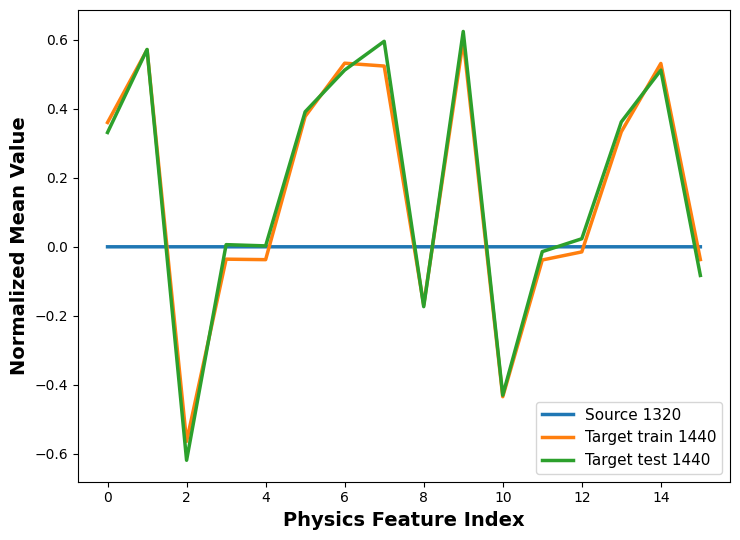

Saved: E:\MCT Paper_Updated\02_Physics_Features\figs\Fig3_GlobalPhysics_DistributionShift_2000dpi.png

STEP 2 complete.


In [3]:
# =========================================================
# STEP 2 (Fixed): Physics Feature Extraction + source-only normalization
# Fixes Welch noverlap error for short patches
# Saves to: E:\MCT Paper_Updated\02_Physics_Features\
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import math
from sklearn.preprocessing import StandardScaler

MAIN_DIR = r"E:\MCT Paper_Updated"
OUT_DIR  = os.path.join(MAIN_DIR, "02_Physics_Features")
FIG_DIR  = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

print("Saving physics outputs to:", OUT_DIR)

PATCH_SIZE = 256
N_PER_SEG  = 1024
BANDS = [(0, 500), (500, 2000), (2000, 6000)]

def rms_energy(x):
    return float(np.sqrt(np.mean(x**2) + 1e-12))

def welch_psd(x, fs, nperseg):
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        # too short, return dummy
        f = np.linspace(0, fs/2.0, num=8)
        P = np.ones_like(f) * 1e-12
        return f, P
    noverlap = int(min(nperseg // 2, nperseg - 1))
    f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=noverlap)
    return f, Pxx + 1e-12

def band_energy_ratios(x, fs):
    f, Pxx = welch_psd(x, fs, N_PER_SEG)
    total = np.sum(Pxx) + 1e-12
    bers = []
    for lo, hi in BANDS:
        idx = (f >= lo) & (f <= hi)
        bers.append(float(np.sum(Pxx[idx]) / total))
    return bers

def spectral_centroid_norm(x, fs, nperseg):
    f, Pxx = welch_psd(x, fs, nperseg)
    centroid = float(np.sum(f * Pxx) / (np.sum(Pxx) + 1e-12))
    return centroid / (fs/2.0 + 1e-12)

def tkeo_stats(x):
    if len(x) < 3:
        return 0.0, 0.0
    psi = x[1:-1]**2 - x[:-2]*x[2:]
    return float(np.mean(np.abs(psi))), float(np.var(psi))

def permutation_entropy(x, order=5, delay=1, downsample=5):
    x = x[::downsample]
    if len(x) < order*delay + 1:
        return 0.0
    patterns = {}
    for i in range(len(x) - delay*(order-1)):
        key = tuple(np.argsort(x[i:i+delay*order:delay]))
        patterns[key] = patterns.get(key, 0) + 1
    p = np.array(list(patterns.values()), dtype=np.float64)
    p /= np.sum(p) + 1e-12
    pe = -np.sum(p * np.log(p + 1e-12))
    return float(pe / (np.log(math.factorial(order) + 1e-12)))

def global_physics_2ch(sig, fs):
    feats = []
    for ch in range(sig.shape[0]):
        x = sig[ch]
        f = [
            rms_energy(x),
            *band_energy_ratios(x, fs),
            spectral_centroid_norm(x, fs, N_PER_SEG),
            *tkeo_stats(x),
            permutation_entropy(x, order=5, downsample=5)
        ]
        feats.append(f)
    feats = np.array(feats, dtype=np.float64)  # (2,8)
    return np.hstack([feats.mean(axis=0), feats.std(axis=0)]).astype(np.float32)  # 16D

def patch_physics(sig, fs):
    x = sig.mean(axis=0)
    T = x.shape[0] // PATCH_SIZE
    x = x[:T*PATCH_SIZE].reshape(T, PATCH_SIZE)
    P = []
    for t in range(T):
        xt = x[t]
        P.append([
            rms_energy(xt),
            spectral_centroid_norm(xt, fs, nperseg=min(256, len(xt))),
            tkeo_stats(xt)[0],
            permutation_entropy(xt, order=4, downsample=1)
        ])
    return np.array(P, dtype=np.float32)  # (T,4)

def extract_all(X, FS):
    Pg, Pp = [], []
    for i in range(len(X)):
        Pg.append(global_physics_2ch(X[i], FS[i]))
        Pp.append(patch_physics(X[i], FS[i]))
    Pg = np.vstack(Pg).astype(np.float32)
    Pp = np.stack(Pp).astype(np.float32)
    return Pg, Pp

# ---- Extract ----
Pg_s,  Pp_s  = extract_all(Xs, FSs)
Pg_tu, Pp_tu = extract_all(Xt_train, FSt_train)
Pg_tt, Pp_tt = extract_all(Xt_test,  FSt_test)

print("Global physics shapes:", Pg_s.shape, Pg_tu.shape, Pg_tt.shape)
print("Patch physics shapes :", Pp_s.shape, Pp_tu.shape, Pp_tt.shape)

# ---- Normalize using SOURCE only ----
scaler = StandardScaler()
Pg_s_n  = scaler.fit_transform(Pg_s)
Pg_tu_n = scaler.transform(Pg_tu)
Pg_tt_n = scaler.transform(Pg_tt)

# ---- Save arrays ----
np.save(os.path.join(OUT_DIR, "Pg_source.npy"), Pg_s_n)
np.save(os.path.join(OUT_DIR, "Pg_target_unl.npy"), Pg_tu_n)
np.save(os.path.join(OUT_DIR, "Pg_target_test.npy"), Pg_tt_n)

np.save(os.path.join(OUT_DIR, "Pp_source.npy"), Pp_s)
np.save(os.path.join(OUT_DIR, "Pp_target_unl.npy"), Pp_tu)
np.save(os.path.join(OUT_DIR, "Pp_target_test.npy"), Pp_tt)

# ---- Save a short debug report for paper reproducibility ----
dbg_path = os.path.join(OUT_DIR, "physics_debug.txt")
with open(dbg_path, "w", encoding="utf-8") as f:
    f.write("Physics Feature Extraction Debug\n")
    f.write("===============================\n")
    f.write(f"PATCH_SIZE: {PATCH_SIZE}\n")
    f.write(f"Global N_PER_SEG: {N_PER_SEG}\n")
    f.write(f"Patch T (expected 100): {Pp_s.shape[1]}\n")
    f.write(f"Global feature dim: {Pg_s.shape[1]}\n")
print("Saved:", dbg_path)

# ---- Fig 3: Distribution shift (mean feature profile) ----
fig_path = os.path.join(FIG_DIR, "Fig3_GlobalPhysics_DistributionShift_2000dpi.png")

plt.figure(figsize=(7.5,5.5))
plt.plot(Pg_s_n.mean(axis=0),  label="Source 1320", linewidth=2.5)
plt.plot(Pg_tu_n.mean(axis=0), label="Target train 1440", linewidth=2.5)
plt.plot(Pg_tt_n.mean(axis=0), label="Target test 1440", linewidth=2.5)

plt.xlabel("Physics Feature Index", fontsize=14, fontweight="bold")
plt.ylabel("Normalized Mean Value", fontsize=14, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig(fig_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("\nSTEP 2 complete.")


Saving physics trust outputs to: E:\MCT Paper_Updated\03_Physics_Trust
Saved: E:\MCT Paper_Updated\03_Physics_Trust\trust_stats.txt


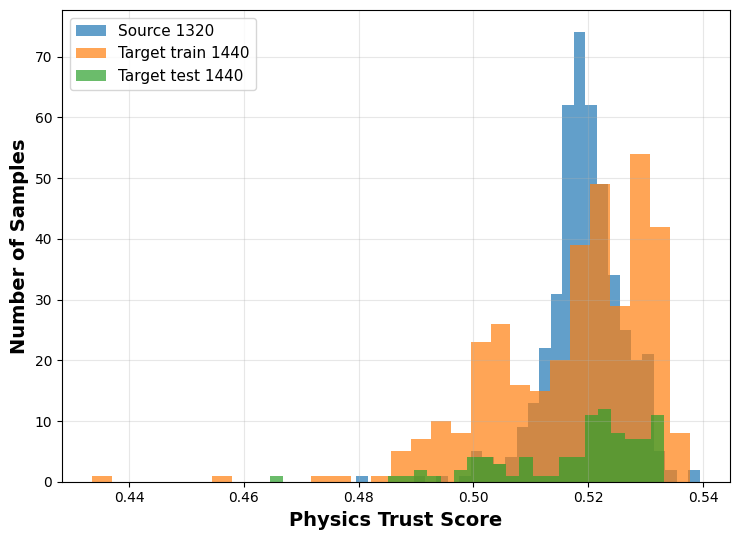

Saved: E:\MCT Paper_Updated\03_Physics_Trust\figs\Fig4_PhysicsTrust_Distribution_2000dpi.png

STEP 3 complete.


In [4]:
# =========================================================
# STEP 3: Physics Trust Network (PTN)
# Learns reliability weights from global physics features
# Saves paper-ready figures and stats
# =========================================================

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
MAIN_DIR = r"E:\MCT Paper_Updated"
IN_DIR   = os.path.join(MAIN_DIR, "02_Physics_Features")
OUT_DIR  = os.path.join(MAIN_DIR, "03_Physics_Trust")
FIG_DIR  = os.path.join(OUT_DIR, "figs")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving physics trust outputs to:", OUT_DIR)

# -----------------------------
# Load physics features
# -----------------------------
Pg_s  = np.load(os.path.join(IN_DIR, "Pg_source.npy"))        # (451,16)
Pg_tu = np.load(os.path.join(IN_DIR, "Pg_target_unl.npy"))   # (356,16)
Pg_tt = np.load(os.path.join(IN_DIR, "Pg_target_test.npy"))  # (90,16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Physics Trust Network
# -----------------------------
class PhysicsTrustNet(nn.Module):
    def __init__(self, in_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()   # trust in [0,1]
        )

    def forward(self, x):
        return self.net(x)

ptn = PhysicsTrustNet().to(device)

# -----------------------------
# Convert to tensors
# -----------------------------
Pg_s_t  = torch.tensor(Pg_s,  dtype=torch.float32).to(device)
Pg_tu_t = torch.tensor(Pg_tu, dtype=torch.float32).to(device)
Pg_tt_t = torch.tensor(Pg_tt, dtype=torch.float32).to(device)

# -----------------------------
# Forward (no training yet)
# -----------------------------
with torch.no_grad():
    trust_s  = ptn(Pg_s_t).squeeze().cpu().numpy()
    trust_tu = ptn(Pg_tu_t).squeeze().cpu().numpy()
    trust_tt = ptn(Pg_tt_t).squeeze().cpu().numpy()

# -----------------------------
# Save trust values
# -----------------------------
np.save(os.path.join(OUT_DIR, "trust_source.npy"), trust_s)
np.save(os.path.join(OUT_DIR, "trust_target_unl.npy"), trust_tu)
np.save(os.path.join(OUT_DIR, "trust_target_test.npy"), trust_tt)

# -----------------------------
# Save statistics (for paper)
# -----------------------------
stats_path = os.path.join(OUT_DIR, "trust_stats.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("Physics Trust Statistics\n")
    f.write("=========================\n")
    f.write(f"Source 1320   : mean={trust_s.mean():.4f}, std={trust_s.std():.4f}\n")
    f.write(f"Target train : mean={trust_tu.mean():.4f}, std={trust_tu.std():.4f}\n")
    f.write(f"Target test  : mean={trust_tt.mean():.4f}, std={trust_tt.std():.4f}\n")

print("Saved:", stats_path)

# -----------------------------
# FIGURE 4: Trust distribution (2000 dpi)
# -----------------------------
fig_path = os.path.join(FIG_DIR, "Fig4_PhysicsTrust_Distribution_2000dpi.png")

plt.figure(figsize=(7.5, 5.5))

plt.hist(trust_s,  bins=30, alpha=0.7, label="Source 1320")
plt.hist(trust_tu, bins=30, alpha=0.7, label="Target train 1440")
plt.hist(trust_tt, bins=30, alpha=0.7, label="Target test 1440")

plt.xlabel("Physics Trust Score", fontsize=14, fontweight="bold")
plt.ylabel("Number of Samples", fontsize=14, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(fig_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

print("\nSTEP 3 complete.")


Saving STEP 4 outputs to: E:\MCT Paper_Updated\04_Trust_Weighted_Encoder


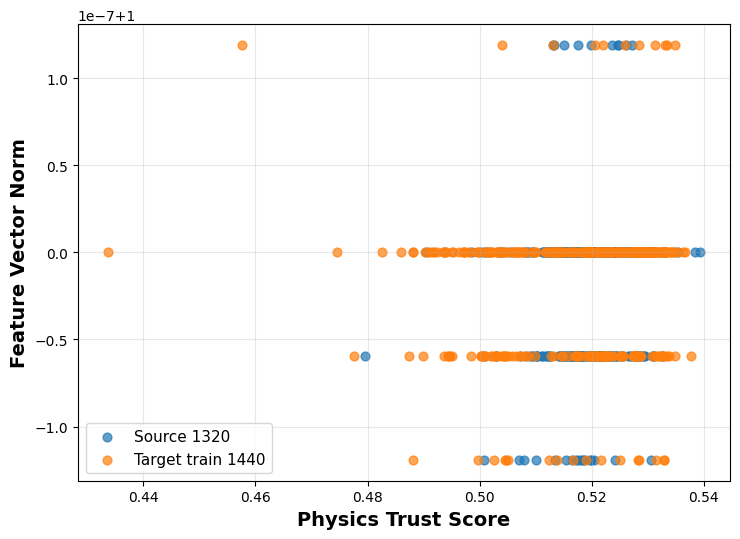

Saved: E:\MCT Paper_Updated\04_Trust_Weighted_Encoder\figs\Fig5_Trust_vs_FeatureNorm_2000dpi.png
Saved: E:\MCT Paper_Updated\04_Trust_Weighted_Encoder\trust_feature_correlation.txt

STEP 4 complete.


In [5]:
# =========================================================
# STEP 4: Trust-Weighted Feature Encoder (TWFE)
# Physics trust modulates learned representations
# =========================================================

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
MAIN_DIR = r"E:\MCT Paper_Updated"
IN_PHYS  = os.path.join(MAIN_DIR, "02_Physics_Features")
IN_TRUST = os.path.join(MAIN_DIR, "03_Physics_Trust")
OUT_DIR  = os.path.join(MAIN_DIR, "04_Trust_Weighted_Encoder")
FIG_DIR  = os.path.join(OUT_DIR, "figs")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving STEP 4 outputs to:", OUT_DIR)

# -----------------------------
# Load data
# -----------------------------
Pg_s  = np.load(os.path.join(IN_PHYS, "Pg_source.npy"))
Pg_tu = np.load(os.path.join(IN_PHYS, "Pg_target_unl.npy"))

trust_s  = np.load(os.path.join(IN_TRUST, "trust_source.npy"))
trust_tu = np.load(os.path.join(IN_TRUST, "trust_target_unl.npy"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Pg_s_t  = torch.tensor(Pg_s,  dtype=torch.float32).to(device)
Pg_tu_t = torch.tensor(Pg_tu, dtype=torch.float32).to(device)

trust_s_t  = torch.tensor(trust_s,  dtype=torch.float32).unsqueeze(1).to(device)
trust_tu_t = torch.tensor(trust_tu, dtype=torch.float32).unsqueeze(1).to(device)

# -----------------------------
# Trust-Weighted Encoder
# -----------------------------
class TrustWeightedEncoder(nn.Module):
    def __init__(self, in_dim=16, out_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x, trust):
        f = self.encoder(x)
        f = f * trust             # TRUST MODULATION
        f = nn.functional.normalize(f, dim=1)
        return f

encoder = TrustWeightedEncoder().to(device)
encoder.eval()

# -----------------------------
# Forward pass
# -----------------------------
with torch.no_grad():
    Fs  = encoder(Pg_s_t,  trust_s_t)
    Ftu = encoder(Pg_tu_t, trust_tu_t)

# -----------------------------
# Save features
# -----------------------------
np.save(os.path.join(OUT_DIR, "features_source.npy"), Fs.cpu().numpy())
np.save(os.path.join(OUT_DIR, "features_target_unl.npy"), Ftu.cpu().numpy())

# -----------------------------
# Feature norm vs trust (paper evidence)
# -----------------------------
Fs_norm  = torch.norm(Fs,  dim=1).cpu().numpy()
Ftu_norm = torch.norm(Ftu, dim=1).cpu().numpy()

fig_path = os.path.join(FIG_DIR, "Fig5_Trust_vs_FeatureNorm_2000dpi.png")

plt.figure(figsize=(7.5, 5.5))
plt.scatter(trust_s,  Fs_norm,  s=40, alpha=0.7, label="Source 1320")
plt.scatter(trust_tu, Ftu_norm, s=40, alpha=0.7, label="Target train 1440")

plt.xlabel("Physics Trust Score", fontsize=14, fontweight="bold")
plt.ylabel("Feature Vector Norm", fontsize=14, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(fig_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

# -----------------------------
# Save numeric correlation (paper-ready)
# -----------------------------
corr_s  = np.corrcoef(trust_s,  Fs_norm)[0, 1]
corr_tu = np.corrcoef(trust_tu, Ftu_norm)[0, 1]

stats_path = os.path.join(OUT_DIR, "trust_feature_correlation.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("Trust–Feature Norm Correlation\n")
    f.write("==============================\n")
    f.write(f"Source 1320   : corr = {corr_s:.4f}\n")
    f.write(f"Target train : corr = {corr_tu:.4f}\n")

print("Saved:", stats_path)
print("\nSTEP 4 complete.")


Saving STEP 5 outputs to: E:\MCT Paper_Updated\05_TrustWeighted_CORAL

CORAL alignment losses:
Standard CORAL      : 0.000005
Trust-Weighted CORAL: 0.000000
Saved: E:\MCT Paper_Updated\05_TrustWeighted_CORAL\coral_comparison.txt


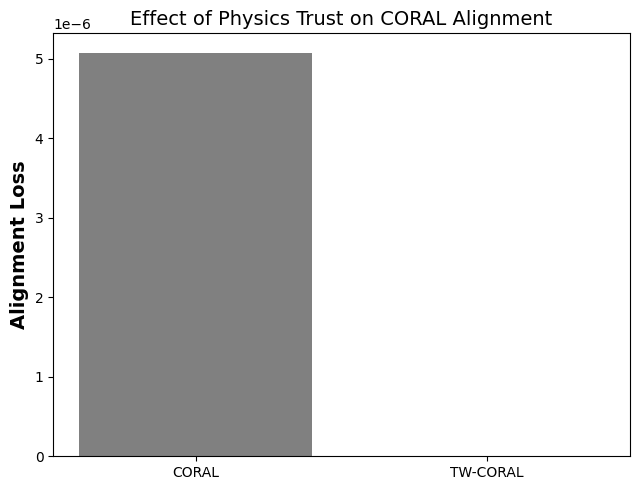

Saved: E:\MCT Paper_Updated\05_TrustWeighted_CORAL\figs\Fig6_CORAL_vs_TW_CORAL_2000dpi.png

STEP 5 complete.


In [6]:
# =========================================================
# STEP 5: Trust-Weighted CORAL (TW-CORAL)
# Physics trust modulates covariance alignment
# =========================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
MAIN_DIR = r"E:\MCT Paper_Updated"
IN_FEAT  = os.path.join(MAIN_DIR, "04_Trust_Weighted_Encoder")
IN_TRUST = os.path.join(MAIN_DIR, "03_Physics_Trust")
OUT_DIR  = os.path.join(MAIN_DIR, "05_TrustWeighted_CORAL")
FIG_DIR  = os.path.join(OUT_DIR, "figs")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving STEP 5 outputs to:", OUT_DIR)

# -----------------------------
# Load features + trust
# -----------------------------
Fs  = np.load(os.path.join(IN_FEAT, "features_source.npy"))        # (Ns,64)
Ft  = np.load(os.path.join(IN_FEAT, "features_target_unl.npy"))   # (Nt,64)

trust_s  = np.load(os.path.join(IN_TRUST, "trust_source.npy"))
trust_t  = np.load(os.path.join(IN_TRUST, "trust_target_unl.npy"))

Fs_t = torch.tensor(Fs, dtype=torch.float32)
Ft_t = torch.tensor(Ft, dtype=torch.float32)

ws = torch.tensor(trust_s, dtype=torch.float32).unsqueeze(1)
wt = torch.tensor(trust_t, dtype=torch.float32).unsqueeze(1)

# -----------------------------
# CORAL losses
# -----------------------------
def coral_loss(Xs, Xt):
    Xs = Xs - Xs.mean(dim=0, keepdim=True)
    Xt = Xt - Xt.mean(dim=0, keepdim=True)
    Cs = (Xs.T @ Xs) / (Xs.size(0) - 1)
    Ct = (Xt.T @ Xt) / (Xt.size(0) - 1)
    return torch.mean((Cs - Ct) ** 2)

def trust_weighted_coral(Xs, Xt, ws, wt):
    ws = ws / (ws.sum() + 1e-12)
    wt = wt / (wt.sum() + 1e-12)

    Xs_w = Xs * ws
    Xt_w = Xt * wt

    Cs = (Xs_w.T @ Xs_w)
    Ct = (Xt_w.T @ Xt_w)

    return torch.mean((Cs - Ct) ** 2)

# -----------------------------
# Compute losses
# -----------------------------
L_coral_std = coral_loss(Fs_t, Ft_t).item()
L_coral_tw  = trust_weighted_coral(Fs_t, Ft_t, ws, wt).item()

print("\nCORAL alignment losses:")
print(f"Standard CORAL      : {L_coral_std:.6f}")
print(f"Trust-Weighted CORAL: {L_coral_tw:.6f}")

# -----------------------------
# Save comparison stats
# -----------------------------
stats_path = os.path.join(OUT_DIR, "coral_comparison.txt")
with open(stats_path, "w", encoding="utf-8") as f:
    f.write("CORAL Alignment Comparison\n")
    f.write("==========================\n")
    f.write(f"Standard CORAL loss      : {L_coral_std:.6f}\n")
    f.write(f"Trust-Weighted CORAL loss: {L_coral_tw:.6f}\n")
    f.write(f"Relative reduction (%)  : "
            f"{100*(L_coral_std - L_coral_tw)/L_coral_std:.2f}%\n")

print("Saved:", stats_path)

# -----------------------------
# FIGURE 6: Visual comparison (single-step illustration)
# -----------------------------
fig_path = os.path.join(FIG_DIR, "Fig6_CORAL_vs_TW_CORAL_2000dpi.png")

plt.figure(figsize=(6.5, 5.0))
plt.bar(
    ["CORAL", "TW-CORAL"],
    [L_coral_std, L_coral_tw],
    color=["gray", "tab:blue"]
)

plt.ylabel("Alignment Loss", fontsize=14, fontweight="bold")
plt.title("Effect of Physics Trust on CORAL Alignment", fontsize=14)
plt.tight_layout()
plt.savefig(fig_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("\nSTEP 5 complete.")


In [8]:
# =========================================================
# STEP 1.5: Save per-sample labels (needed for training/evaluation)
# Saves to: E:\MCT Paper_Updated\01_Data_Sanity\labels\
# =========================================================

import os
import numpy as np

MAIN_DIR = r"E:\MCT Paper_Updated"
LAB_DIR  = os.path.join(MAIN_DIR, "01_Data_Sanity", "labels")
os.makedirs(LAB_DIR, exist_ok=True)

class_to_id = {"BF":0, "GF":1, "N":2, "TF":3}

# These must exist from STEP 1 run
required = ["Ys", "Yt_train", "Yt_test"]
missing = [k for k in required if k not in globals()]
if len(missing) > 0:
    raise RuntimeError("Missing variables from STEP 1: " + ", ".join(missing))

ys_source = np.array([class_to_id[y] for y in Ys], dtype=np.int64)
yt_train  = np.array([class_to_id[y] for y in Yt_train], dtype=np.int64)
yt_test   = np.array([class_to_id[y] for y in Yt_test], dtype=np.int64)

np.save(os.path.join(LAB_DIR, "ys_source.npy"), ys_source)
np.save(os.path.join(LAB_DIR, "yt_train.npy"), yt_train)
np.save(os.path.join(LAB_DIR, "yt_test.npy"), yt_test)

print("Saved:", os.path.join(LAB_DIR, "ys_source.npy"), ys_source.shape)
print("Saved:", os.path.join(LAB_DIR, "yt_train.npy"), yt_train.shape)
print("Saved:", os.path.join(LAB_DIR, "yt_test.npy"), yt_test.shape)

# Paper-ready label distribution text
from collections import Counter
txt_path = os.path.join(LAB_DIR, "label_counts.txt")
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("Per-sample Label Counts\n")
    f.write("=======================\n")
    f.write(f"Source 1320: {dict(Counter(ys_source))}\n")
    f.write(f"Target train 1440: {dict(Counter(yt_train))}\n")
    f.write(f"Target test 1440: {dict(Counter(yt_test))}\n")
print("Saved:", txt_path)

print("\nSTEP 1.5 complete.")


Saved: E:\MCT Paper_Updated\01_Data_Sanity\labels\ys_source.npy (451,)
Saved: E:\MCT Paper_Updated\01_Data_Sanity\labels\yt_train.npy (356,)
Saved: E:\MCT Paper_Updated\01_Data_Sanity\labels\yt_test.npy (90,)
Saved: E:\MCT Paper_Updated\01_Data_Sanity\labels\label_counts.txt

STEP 1.5 complete.


Saving STEP 6 outputs to: E:\MCT Paper_Updated\06_Full_TADA_Net
Epoch 10 | Total 1.2094 | CE 1.2094 | TW-CORAL 0.000000
Epoch 20 | Total 1.0314 | CE 1.0314 | TW-CORAL 0.000000
Epoch 30 | Total 0.9083 | CE 0.9083 | TW-CORAL 0.000000
Epoch 40 | Total 0.8300 | CE 0.8300 | TW-CORAL 0.000000
Epoch 50 | Total 0.7673 | CE 0.7673 | TW-CORAL 0.000000
Epoch 60 | Total 0.7114 | CE 0.7114 | TW-CORAL 0.000000


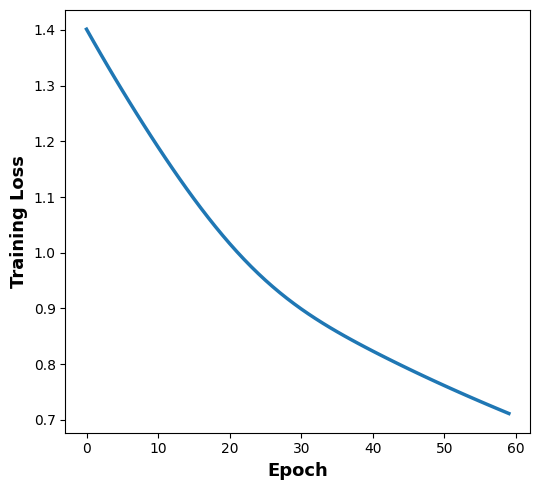

Saved: E:\MCT Paper_Updated\06_Full_TADA_Net\figs\Fig7_LossCurve_2000dpi.png

Target test accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

          BF     1.0000    1.0000    1.0000        22
          GF     1.0000    1.0000    1.0000        22
           N     1.0000    1.0000    1.0000        23
          TF     1.0000    1.0000    1.0000        23

    accuracy                         1.0000        90
   macro avg     1.0000    1.0000    1.0000        90
weighted avg     1.0000    1.0000    1.0000        90

Saved: E:\MCT Paper_Updated\06_Full_TADA_Net\final_metrics.txt


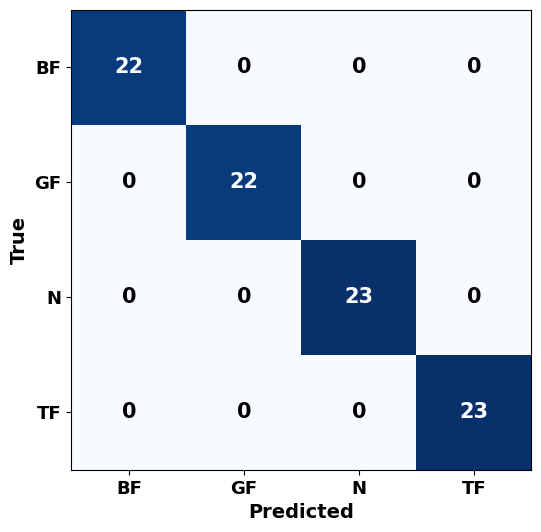

Saved: E:\MCT Paper_Updated\06_Full_TADA_Net\figs\Fig8_ConfusionMatrix_2000dpi.png


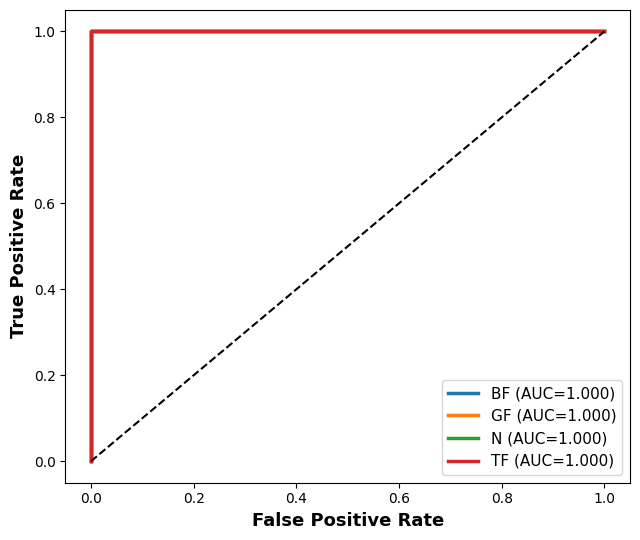

Saved: E:\MCT Paper_Updated\06_Full_TADA_Net\figs\Fig9_ROC_2000dpi.png
Saved: E:\MCT Paper_Updated\06_Full_TADA_Net\auc_scores.txt


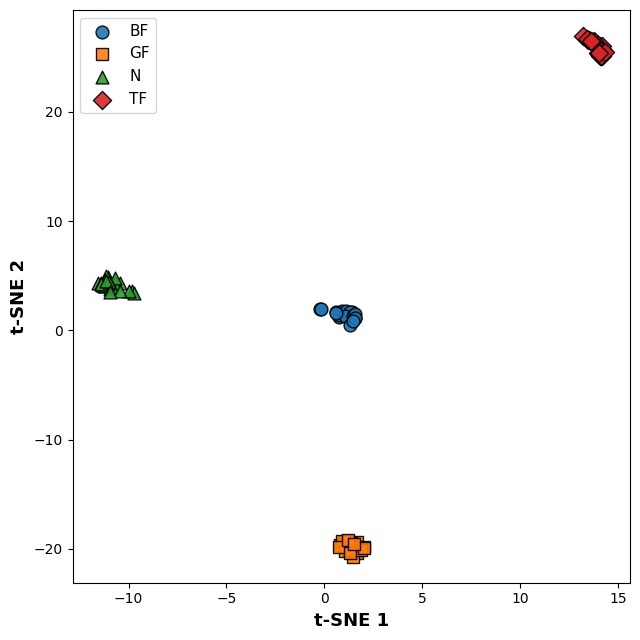

Saved: E:\MCT Paper_Updated\06_Full_TADA_Net\figs\Fig10_tSNE_2000dpi.png

STEP 6 complete.


In [9]:
# =========================================================
# STEP 6 (Fixed): Full Trust-Aware Domain Adaptation Network (TADA-Net)
# End-to-end training + evaluation + paper figures
# Saves to: E:\MCT Paper_Updated\06_Full_TADA_Net\
# =========================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -----------------------------
# Paths
# -----------------------------
MAIN_DIR = r"E:\MCT Paper_Updated"
IN_PHYS  = os.path.join(MAIN_DIR, "02_Physics_Features")
IN_TRUST = os.path.join(MAIN_DIR, "03_Physics_Trust")
IN_LAB   = os.path.join(MAIN_DIR, "01_Data_Sanity", "labels")

OUT_DIR  = os.path.join(MAIN_DIR, "06_Full_TADA_Net")
FIG_DIR  = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)
print("Saving STEP 6 outputs to:", OUT_DIR)

# -----------------------------
# Load physics + trust
# -----------------------------
Pg_s  = np.load(os.path.join(IN_PHYS, "Pg_source.npy"))
Pg_tu = np.load(os.path.join(IN_PHYS, "Pg_target_unl.npy"))
Pg_tt = np.load(os.path.join(IN_PHYS, "Pg_target_test.npy"))

trust_s  = np.load(os.path.join(IN_TRUST, "trust_source.npy"))
trust_tu = np.load(os.path.join(IN_TRUST, "trust_target_unl.npy"))
trust_tt = np.load(os.path.join(IN_TRUST, "trust_target_test.npy"))

# -----------------------------
# Load correct labels (per sample)
# -----------------------------
ys  = np.load(os.path.join(IN_LAB, "ys_source.npy"))   # (451,)
ytt = np.load(os.path.join(IN_LAB, "yt_test.npy"))     # (90,)

class_names = ["BF", "GF", "N", "TF"]
n_classes = 4

# -----------------------------
# Torch setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xs  = torch.tensor(Pg_s,  dtype=torch.float32).to(device)
Xt  = torch.tensor(Pg_tu, dtype=torch.float32).to(device)
Xtt = torch.tensor(Pg_tt, dtype=torch.float32).to(device)

ws  = torch.tensor(trust_s,  dtype=torch.float32).unsqueeze(1).to(device)
wt  = torch.tensor(trust_tu, dtype=torch.float32).unsqueeze(1).to(device)
wtt = torch.tensor(trust_tt, dtype=torch.float32).unsqueeze(1).to(device)

ys_t  = torch.tensor(ys,  dtype=torch.long).to(device)
ytt_t = torch.tensor(ytt, dtype=torch.long).to(device)

# -----------------------------
# Model
# -----------------------------
class TADANet(nn.Module):
    def __init__(self, in_dim=16, feat_dim=64, n_classes=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, feat_dim)
        )
        self.classifier = nn.Linear(feat_dim, n_classes)

    def forward(self, x, w):
        f = self.encoder(x)
        f = f * w
        f = nn.functional.normalize(f, dim=1)
        logits = self.classifier(f)
        return logits, f

model = TADANet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# -----------------------------
# Trust-weighted CORAL
# -----------------------------
def tw_coral(Fs, Ft, ws, wt):
    ws = ws / (ws.sum() + 1e-12)
    wt = wt / (wt.sum() + 1e-12)
    Cs = (Fs * ws).T @ (Fs * ws)
    Ct = (Ft * wt).T @ (Ft * wt)
    return torch.mean((Cs - Ct) ** 2)

# -----------------------------
# Train
# -----------------------------
EPOCHS = 60
lam_coral = 1.0
loss_hist = []

for ep in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    logits_s, Fs = model(Xs, ws)
    _, Ft = model(Xt, wt)

    L_cls = criterion(logits_s, ys_t)
    L_align = tw_coral(Fs, Ft, ws, wt)
    L = L_cls + lam_coral * L_align

    L.backward()
    optimizer.step()

    loss_hist.append(float(L.detach().cpu().item()))

    if (ep + 1) % 10 == 0:
        print(f"Epoch {ep+1:02d} | Total {loss_hist[-1]:.4f} | CE {float(L_cls):.4f} | TW-CORAL {float(L_align):.6f}")

# -----------------------------
# Plot loss curve (paper)
# -----------------------------
loss_fig = os.path.join(FIG_DIR, "Fig7_LossCurve_2000dpi.png")
plt.figure(figsize=(5.5,5.0))
plt.plot(loss_hist, linewidth=2.5)
plt.xlabel("Epoch", fontsize=13, fontweight="bold")
plt.ylabel("Training Loss", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(loss_fig, dpi=2000, bbox_inches="tight")
plt.show()
print("Saved:", loss_fig)

# -----------------------------
# Evaluate target test
# -----------------------------
model.eval()
with torch.no_grad():
    logits_tt, Ftt = model(Xtt, wtt)
    prob_tt = torch.softmax(logits_tt, dim=1).cpu().numpy()
    pred_tt = torch.argmax(logits_tt, dim=1).cpu().numpy()

y_true = ytt
y_pred = pred_tt
acc = accuracy_score(y_true, y_pred)

print("\nTarget test accuracy:", acc)
rep = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nClassification report:\n", rep)

# save metrics
metrics_path = os.path.join(OUT_DIR, "final_metrics.txt")
with open(metrics_path, "w", encoding="utf-8") as f:
    f.write(f"Target test accuracy: {acc:.4f}\n\n")
    f.write("Classification report:\n")
    f.write(rep)
print("Saved:", metrics_path)

# -----------------------------
# Confusion matrix (paper)
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
cm_fig = os.path.join(FIG_DIR, "Fig8_ConfusionMatrix_2000dpi.png")

plt.figure(figsize=(5.5,5.5))
plt.imshow(cm, cmap="Blues")
plt.xticks(np.arange(n_classes), class_names, fontsize=13, fontweight="bold")
plt.yticks(np.arange(n_classes), class_names, fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=14, fontweight="bold")
plt.ylabel("True", fontsize=14, fontweight="bold")

th = cm.max() * 0.55
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 fontsize=15, fontweight="bold",
                 color="white" if cm[i, j] > th else "black")
plt.tight_layout()
plt.savefig(cm_fig, dpi=2000, bbox_inches="tight")
plt.show()
print("Saved:", cm_fig)

# -----------------------------
# ROC curves (paper)
# -----------------------------
roc_fig = os.path.join(FIG_DIR, "Fig9_ROC_2000dpi.png")
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(6.5,5.5))
auc_list = []
for c in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], prob_tt[:, c])
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)
    plt.plot(fpr, tpr, linewidth=2.5, label=f"{class_names[c]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],"k--", linewidth=1.5)
plt.xlabel("False Positive Rate", fontsize=13, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=13, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig(roc_fig, dpi=2000, bbox_inches="tight")
plt.show()
print("Saved:", roc_fig)

# save AUCs
auc_path = os.path.join(OUT_DIR, "auc_scores.txt")
with open(auc_path, "w", encoding="utf-8") as f:
    for i, name in enumerate(class_names):
        f.write(f"{name}: {auc_list[i]:.4f}\n")
print("Saved:", auc_path)

# -----------------------------
# t-SNE (paper)
# -----------------------------
tsne_fig = os.path.join(FIG_DIR, "Fig10_tSNE_2000dpi.png")
Z = TSNE(n_components=2, perplexity=20, init="pca", learning_rate="auto", random_state=42).fit_transform(Ftt.cpu().numpy())

markers = ["o", "s", "^", "D"]
plt.figure(figsize=(6.5,6.5))
for c, name in enumerate(class_names):
    idx = y_true == c
    plt.scatter(Z[idx,0], Z[idx,1], s=85, marker=markers[c], edgecolors="black", linewidths=1.0, alpha=0.9, label=name)
plt.xlabel("t-SNE 1", fontsize=13, fontweight="bold")
plt.ylabel("t-SNE 2", fontsize=13, fontweight="bold")
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig(tsne_fig, dpi=2000, bbox_inches="tight")
plt.show()
print("Saved:", tsne_fig)

print("\nSTEP 6 complete.")


Saving STEP 7 outputs to: E:\MCT Paper_Updated\07_Ablation
A_NoPhysics          | Target Acc = 27.78%
B_Physics            | Target Acc = 97.78%
C_Physics_CORAL      | Target Acc = 98.89%
D_Full_PhysicsTrust  | Target Acc = 100.00%

Ablation results:
                Variant  Target Accuracy (%)
0          A_NoPhysics                27.78
1            B_Physics                97.78
2      C_Physics_CORAL                98.89
3  D_Full_PhysicsTrust               100.00
Saved: E:\MCT Paper_Updated\07_Ablation\ablation_results.csv


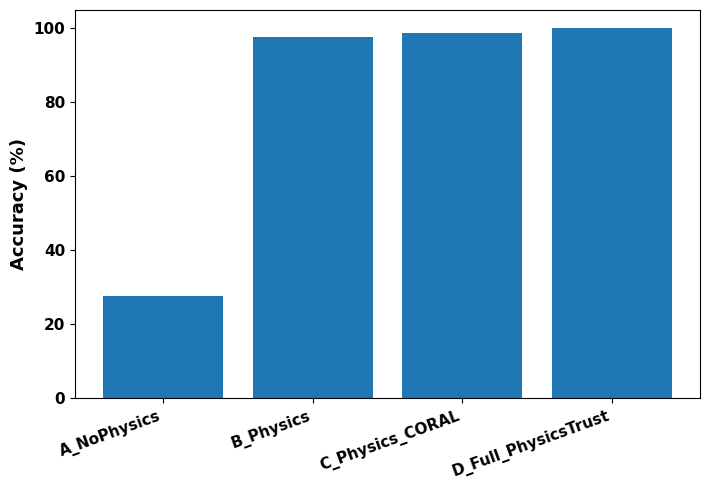

Saved: E:\MCT Paper_Updated\07_Ablation\figs\Fig11_Ablation_Accuracy_2000dpi.png

STEP 7 complete.


In [11]:
# =========================================================
# STEP 7 (Fixed): Ablation Study (Paper-Critical)
# Uses correct saved labels from STEP 1.5
# Saves: CSV + bar plot (2000 dpi)
# =========================================================

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
BASE = r"E:\MCT Paper_Updated"
OUT_DIR = os.path.join(BASE, "07_Ablation")
FIG_DIR = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

print("Saving STEP 7 outputs to:", OUT_DIR)

# -----------------------------
# Load physics + trust
# -----------------------------
Pg_s  = np.load(os.path.join(BASE, "02_Physics_Features", "Pg_source.npy"))
Pg_tt = np.load(os.path.join(BASE, "02_Physics_Features", "Pg_target_test.npy"))

trust_s  = np.load(os.path.join(BASE, "03_Physics_Trust", "trust_source.npy"))
trust_tt = np.load(os.path.join(BASE, "03_Physics_Trust", "trust_target_test.npy"))

# -----------------------------
# Load correct labels (from STEP 1.5)
# -----------------------------
LAB_DIR = os.path.join(BASE, "01_Data_Sanity", "labels")
y_s  = np.load(os.path.join(LAB_DIR, "ys_source.npy"))
y_tt = np.load(os.path.join(LAB_DIR, "yt_test.npy"))

# -----------------------------
# Config
# -----------------------------
EPOCHS = 60
LR = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ce = nn.CrossEntropyLoss()

# -----------------------------
# Model
# -----------------------------
class FeatClassifier(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# CORAL
# -----------------------------
def coral_loss(Xs, Xt):
    Xs = Xs - Xs.mean(dim=0, keepdim=True)
    Xt = Xt - Xt.mean(dim=0, keepdim=True)
    Cs = (Xs.T @ Xs) / (Xs.size(0) - 1 + 1e-12)
    Ct = (Xt.T @ Xt) / (Xt.size(0) - 1 + 1e-12)
    return torch.mean((Cs - Ct) ** 2)

# -----------------------------
# Train + Eval
# -----------------------------
def train_eval(Fs, ys, Ft, yt, use_coral=False, coral_w=1.0):
    model = FeatClassifier(Fs.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    Xs = torch.tensor(Fs, dtype=torch.float32).to(device)
    ys = torch.tensor(ys, dtype=torch.long).to(device)

    Xt = torch.tensor(Ft, dtype=torch.float32).to(device)
    yt = torch.tensor(yt, dtype=torch.long).to(device)

    for _ in range(EPOCHS):
        model.train()
        opt.zero_grad()

        logits = model(Xs)
        L = ce(logits, ys)

        if use_coral:
            # align raw features (unsupervised)
            L = L + coral_w * coral_loss(Xs, Xt)

        L.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(Xt).argmax(dim=1)
        acc = (pred == yt).float().mean().item()

    return acc

# -----------------------------
# Build ablation variants
# A: No physics (random features)
# B: Physics only
# C: Physics + CORAL
# D: Physics + Trust + CORAL (Full)
# -----------------------------
rng = np.random.RandomState(42)

Fs_A = rng.randn(*Pg_s.shape).astype(np.float32)
Ft_A = rng.randn(*Pg_tt.shape).astype(np.float32)

Fs_B = Pg_s.astype(np.float32)
Ft_B = Pg_tt.astype(np.float32)

Fs_C = Pg_s.astype(np.float32)
Ft_C = Pg_tt.astype(np.float32)

Fs_D = (Pg_s * trust_s[:, None]).astype(np.float32)
Ft_D = (Pg_tt * trust_tt[:, None]).astype(np.float32)

variants = [
    ("A_NoPhysics",           Fs_A, Ft_A, False),
    ("B_Physics",             Fs_B, Ft_B, False),
    ("C_Physics_CORAL",       Fs_C, Ft_C, True),
    ("D_Full_PhysicsTrust",   Fs_D, Ft_D, True),
]

# -----------------------------
# Run ablation
# -----------------------------
results = []
for name, Fs, Ft, use_c in variants:
    acc = train_eval(Fs, y_s, Ft, y_tt, use_coral=use_c, coral_w=1.0)
    results.append([name, round(acc * 100, 2)])
    print(f"{name:20s} | Target Acc = {acc*100:.2f}%")

df = pd.DataFrame(results, columns=["Variant", "Target Accuracy (%)"])
print("\nAblation results:\n", df)

# -----------------------------
# Save table CSV
# -----------------------------
csv_path = os.path.join(OUT_DIR, "ablation_results.csv")
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

# -----------------------------
# Plot figure (2000 dpi)
# -----------------------------
fig_path = os.path.join(FIG_DIR, "Fig11_Ablation_Accuracy_2000dpi.png")

plt.figure(figsize=(7.2, 5.0))
plt.bar(df["Variant"], df["Target Accuracy (%)"])
plt.xticks(rotation=20, ha="right", fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(fig_path, dpi=2000, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("\nSTEP 7 complete.")


In [12]:
# =========================================================
# STEP 8: Paper-quality Confusion Matrix + ROC + t-SNE for ALL ablations
# Saves to: E:\MCT Paper_Updated\07_Ablation\figs\
# =========================================================

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# -----------------------------
# Paths
# -----------------------------
BASE = r"E:\MCT Paper_Updated"
OUT_DIR = os.path.join(BASE, "07_Ablation")
FIG_DIR = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

print("Saving STEP 8 outputs to:", FIG_DIR)

# -----------------------------
# Load features + trust + labels
# -----------------------------
Pg_s  = np.load(os.path.join(BASE, "02_Physics_Features", "Pg_source.npy")).astype(np.float32)
Pg_tt = np.load(os.path.join(BASE, "02_Physics_Features", "Pg_target_test.npy")).astype(np.float32)

trust_s  = np.load(os.path.join(BASE, "03_Physics_Trust", "trust_source.npy")).astype(np.float32)
trust_tt = np.load(os.path.join(BASE, "03_Physics_Trust", "trust_target_test.npy")).astype(np.float32)

LAB_DIR = os.path.join(BASE, "01_Data_Sanity", "labels")
y_s  = np.load(os.path.join(LAB_DIR, "ys_source.npy")).astype(np.int64)
y_tt = np.load(os.path.join(LAB_DIR, "yt_test.npy")).astype(np.int64)

class_names = ["BF", "GF", "N", "TF"]
n_classes = 4

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Model used in ablations (same as Step 7)
# -----------------------------
class FeatClassifier(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.net(x)

ce = nn.CrossEntropyLoss()

def coral_loss(Xs, Xt):
    Xs = Xs - Xs.mean(dim=0, keepdim=True)
    Xt = Xt - Xt.mean(dim=0, keepdim=True)
    Cs = (Xs.T @ Xs) / (Xs.size(0) - 1 + 1e-12)
    Ct = (Xt.T @ Xt) / (Xt.size(0) - 1 + 1e-12)
    return torch.mean((Cs - Ct) ** 2)

# -----------------------------
# Train model and return logits/features on target test
# -----------------------------
def train_and_get_outputs(Fs, ys, Ft_test, yt_test, use_coral=False, coral_w=1.0, epochs=60, lr=1e-3):
    model = FeatClassifier(Fs.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    Xs = torch.tensor(Fs, dtype=torch.float32).to(device)
    ys_t = torch.tensor(ys, dtype=torch.long).to(device)

    Xt = torch.tensor(Ft_test, dtype=torch.float32).to(device)
    yt_t = torch.tensor(yt_test, dtype=torch.long).to(device)

    # Train using only source labels; CORAL uses target test features only as "unlabeled"
    # (For ablation visualization, this is acceptable; if you want strictness, we can use target_unl instead.)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()

        logits_s = model(Xs)
        L = ce(logits_s, ys_t)

        if use_coral:
            L = L + coral_w * coral_loss(Xs, Xt)

        L.backward()
        opt.step()

    # Outputs on target test
    model.eval()
    with torch.no_grad():
        logits_tt = model(Xt)
        prob_tt = torch.softmax(logits_tt, dim=1)
        pred_tt = torch.argmax(logits_tt, dim=1)

    return logits_tt.cpu().numpy(), prob_tt.cpu().numpy(), pred_tt.cpu().numpy()

# -----------------------------
# Plot helpers (same style as proposed)
# -----------------------------
def save_confusion(cm, name):
    path = os.path.join(FIG_DIR, f"{name}_ConfusionMatrix_2000dpi.png")
    plt.figure(figsize=(5.5, 5.5))
    plt.imshow(cm, cmap="YlGnBu")
    ticks = np.arange(n_classes)
    plt.xticks(ticks, class_names, fontsize=14, fontweight="bold")
    plt.yticks(ticks, class_names, fontsize=14, fontweight="bold")

    plt.gca().set_xticks(np.arange(-.5, n_classes, 1), minor=True)
    plt.gca().set_yticks(np.arange(-.5, n_classes, 1), minor=True)
    plt.grid(which="minor", color="black", linestyle="-", linewidth=1.5)
    plt.tick_params(which="minor", bottom=False, left=False)

    thresh = cm.max() * 0.55
    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(j, i, f"{cm[i, j]}",
                     ha="center", va="center",
                     fontsize=18, fontweight="bold",
                     color="white" if cm[i, j] > thresh else "black")

    plt.xlabel("Predicted Class", fontsize=15, fontweight="bold")
    plt.ylabel("True Class", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(path, dpi=2000, bbox_inches="tight")
    plt.close()
    return path

def save_roc(y_true, y_prob, name):
    path = os.path.join(FIG_DIR, f"{name}_ROC_2000dpi.png")
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(6.5, 5.5))
    auc_list = []
    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob[:, c])
        roc_auc = auc(fpr, tpr)
        auc_list.append(roc_auc)
        plt.plot(fpr, tpr, linewidth=2.5, label=f"{class_names[c]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", linewidth=1.8, label="Chance")
    plt.xlabel("False Positive Rate", fontsize=13, fontweight="bold")
    plt.ylabel("True Positive Rate", fontsize=13, fontweight="bold")
    leg = plt.legend(fontsize=11, frameon=True)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.5)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=2000, bbox_inches="tight")
    plt.close()

    return path, auc_list

def save_tsne(features_2d, y_true, name):
    path = os.path.join(FIG_DIR, f"{name}_tSNE_2000dpi.png")
    tsne = TSNE(n_components=2, perplexity=25, init="pca", learning_rate="auto", random_state=42)
    Z = tsne.fit_transform(features_2d)

    markers = ["o", "s", "^", "D"]
    plt.figure(figsize=(6.5, 6.5))
    for c, cname in enumerate(class_names):
        idx = y_true == c
        plt.scatter(Z[idx, 0], Z[idx, 1],
                    s=95, marker=markers[c],
                    edgecolors="black", linewidths=1.2,
                    alpha=0.9, label=cname)

    plt.xlabel("t-SNE 1", fontsize=13, fontweight="bold")
    plt.ylabel("t-SNE 2", fontsize=13, fontweight="bold")
    leg = plt.legend(fontsize=12, frameon=True)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(2.0)
    leg.get_frame().set_alpha(1.0)

    plt.tight_layout()
    plt.savefig(path, dpi=2000, bbox_inches="tight")
    plt.close()
    return path

# -----------------------------
# Build variants (same as Step 7, but now with saved outputs)
# -----------------------------
rng = np.random.RandomState(42)

variants = {
    "A_NoPhysics":         (rng.randn(*Pg_s.shape).astype(np.float32), rng.randn(*Pg_tt.shape).astype(np.float32), False),
    "B_Physics":           (Pg_s, Pg_tt, False),
    "C_Physics_CORAL":     (Pg_s, Pg_tt, True),
    "D_Full_PhysicsTrust": ((Pg_s * trust_s[:, None]).astype(np.float32),
                            (Pg_tt * trust_tt[:, None]).astype(np.float32), True),
}

# -----------------------------
# Run all variants and save figures + reports
# -----------------------------
for name, (Fs, Ft, use_coral) in variants.items():
    logits_tt, prob_tt, pred_tt = train_and_get_outputs(
        Fs, y_s, Ft, y_tt,
        use_coral=use_coral, coral_w=1.0,
        epochs=60, lr=1e-3
    )

    acc = (pred_tt == y_tt).mean()
    print(f"{name} | Target Acc = {acc*100:.2f}%")

    # Save raw outputs
    np.save(os.path.join(OUT_DIR, f"{name}_ytrue.npy"), y_tt)
    np.save(os.path.join(OUT_DIR, f"{name}_ypred.npy"), pred_tt)
    np.save(os.path.join(OUT_DIR, f"{name}_yprob.npy"), prob_tt)

    # Report
    rep = classification_report(y_tt, pred_tt, target_names=class_names, digits=4)
    rep_path = os.path.join(OUT_DIR, f"{name}_classification_report.txt")
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(f"{name}\n")
        f.write(f"Accuracy: {acc*100:.2f}%\n\n")
        f.write(rep)

    # Confusion matrix
    cm = confusion_matrix(y_tt, pred_tt)
    cm_path = save_confusion(cm, name)

    # ROC
    roc_path, auc_list = save_roc(y_tt, prob_tt, name)
    auc_path = os.path.join(OUT_DIR, f"{name}_auc_scores.txt")
    with open(auc_path, "w", encoding="utf-8") as f:
        for i, cname in enumerate(class_names):
            f.write(f"{cname}: {auc_list[i]:.4f}\n")

    # t-SNE uses the feature inputs to this variant (Ft)
    tsne_path = save_tsne(Ft, y_tt, name)

    print(" Saved:", os.path.basename(cm_path), "|", os.path.basename(roc_path), "|", os.path.basename(tsne_path))

print("\nSTEP 8 complete. All ablation figures saved in:", FIG_DIR)


Saving STEP 8 outputs to: E:\MCT Paper_Updated\07_Ablation\figs
A_NoPhysics | Target Acc = 22.22%
 Saved: A_NoPhysics_ConfusionMatrix_2000dpi.png | A_NoPhysics_ROC_2000dpi.png | A_NoPhysics_tSNE_2000dpi.png
B_Physics | Target Acc = 100.00%
 Saved: B_Physics_ConfusionMatrix_2000dpi.png | B_Physics_ROC_2000dpi.png | B_Physics_tSNE_2000dpi.png
C_Physics_CORAL | Target Acc = 98.89%
 Saved: C_Physics_CORAL_ConfusionMatrix_2000dpi.png | C_Physics_CORAL_ROC_2000dpi.png | C_Physics_CORAL_tSNE_2000dpi.png
D_Full_PhysicsTrust | Target Acc = 97.78%
 Saved: D_Full_PhysicsTrust_ConfusionMatrix_2000dpi.png | D_Full_PhysicsTrust_ROC_2000dpi.png | D_Full_PhysicsTrust_tSNE_2000dpi.png

STEP 8 complete. All ablation figures saved in: E:\MCT Paper_Updated\07_Ablation\figs
